In [1]:
%cd ..
# !pip install seaborn

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/cvfm4rehab


In [2]:
from data.utils_strokerehab import strokerehab_load_dataset, LabelUtils, DataPaths
import matplotlib.pyplot as plt

# subsampled test set
ds = strokerehab_load_dataset(
    filter_for_subsampled_testset=True
)

/gpfs/scratch/vhl2022/miniconda3/envs/cvfm4rehab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import numpy as np
np.sum(ds['test']['duration_s']) / 60.

39.21016666666666

In [3]:
full_testset = strokerehab_load_dataset(filter_for_testset=True)
print(len(full_testset['test']['path_l']))
print(len(ds['test']['path_l']))

514
50


In [4]:
import os
from tqdm import tqdm

# 2) walk through every entry’s label‐CSV, build a flat list of durations
paths = full_testset['test']['path_l']
durations = []
for csv_path in tqdm(paths):
    csv_path = os.path.join(DataPaths.RAW_LABEL_DIR, csv_path)
    hand = LabelUtils.get_handedness(csv_path)
    seq = LabelUtils.convert_labels_to_action_sequence(csv_path, hand)
    # pull out only the finite durations
    durations.extend(a['duration'] for a in seq if a['duration'] is not None)

    for a in seq:
        if a['duration'] is None:
            print(f"Action {a} has no duration in path {csv_path}")
        elif a['duration'] > 10:
            print(f"Action {a} has duration {a['duration']} < 0.03 in path {csv_path}")

  1%|          | 3/514 [00:00<00:17, 29.04it/s]

Action {'action': 'transport', 'start_time': 16.419, 'duration': 15.702000000000002} has duration 15.702000000000002 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00047/S00047_feeding2_2.csv
Action {'action': 'transport', 'start_time': 23.237, 'duration': 12.085000000000004} has duration 12.085000000000004 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00047/S00047_feeding1_2.csv


  4%|▍         | 23/514 [00:00<00:13, 36.17it/s]

Action {'action': 'idle', 'start_time': 0.0, 'duration': 12.085} has duration 12.085 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00047/S00047_face wash1_1.csv
Action {'action': 'transport', 'start_time': 18.152, 'duration': 12.736} has duration 12.736 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00047/S00047_feeding3_1.csv
Action {'action': 'transport', 'start_time': 23.237, 'duration': 12.085000000000004} has duration 12.085000000000004 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00047/S00047_feeding1_1.csv


  7%|▋         | 36/514 [00:00<00:12, 38.11it/s]

...

Action {'action': 'idle', 'start_time': 11.45, 'duration': 10.583000000000002} has duration 10.583000000000002 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00026/S00026_drinking2_2.csv
Action {'action': 'idle', 'start_time': 9.283, 'duration': 12.549999999999999} has duration 12.549999999999999 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00026/S00026_drinking3_2.csv


 97%|█████████▋| 498/514 [00:15<00:00, 37.68it/s]

Action {'action': 'idle', 'start_time': 10.417, 'duration': 13.016} has duration 13.016 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00026/S00026_drinking4_2.csv
Action {'action': 'stabilize', 'start_time': 32.7, 'duration': 11.416999999999994} has duration 11.416999999999994 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00026/S00026_brushing5_1.csv


100%|██████████| 514/514 [00:16<00:00, 32.11it/s]

Action {'action': 'idle', 'start_time': 10.417, 'duration': 13.016} has duration 13.016 < 0.03 in path /gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/S00026/S00026_drinking4_1.csv


In [5]:
# Get the percentage below 5 seconds
print(f"Percentage of durations below 5 seconds: {sum(d < 5 for d in durations) / len(durations) * 100:.2f}%")

Percentage of durations below 5 seconds: 97.08%


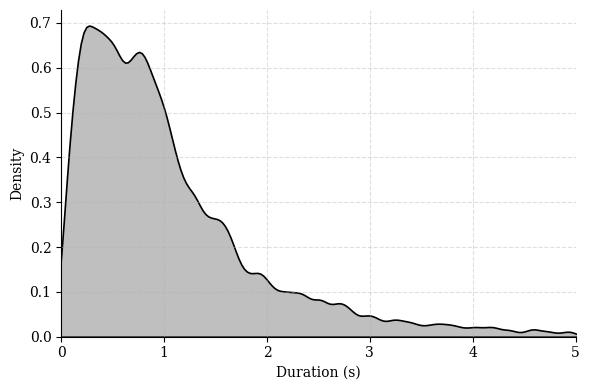

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Use serif font for publication style
mpl.rcParams.update({
    "font.family": "serif",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.edgecolor": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Filter durations
short_durations = [d for d in durations if d < 5]

# KDE plot
plt.figure(figsize=(6, 4))
sns.kdeplot(short_durations, bw_adjust=0.5, fill=True, color="black", linewidth=1.2)

plt.xlabel("Duration (s)")
plt.ylabel("Density")
# plt.title("KDE of durations < 5 seconds", fontsize=14, fontweight='semibold')
plt.xlim(0, 5)
plt.grid(True)
plt.tight_layout()
# Save as PDF
plt.savefig("duration_kde.pdf", format='pdf', bbox_inches='tight')
# plt.show()

In [7]:
import numpy as np
import pandas as pd

# 3) compute cumulative counts & percents at 0.1s bins
thresholds = np.arange(0.05, 1.1, 0.05)
thresholds = np.append(thresholds, 1. / 30)
thresholds = np.append(thresholds, 5)  # include 5 seconds as the last threshold
stats = []
for t in thresholds:
    cnt = sum(d <= t for d in durations)
    pct = cnt / len(durations) * 100
    stats.append({'≤ t (s)': round(t, 2), 'count': cnt, 'percent (%)': round(pct, 2)})

df_stats = pd.DataFrame(stats)

# 4) print the table
print(df_stats)

    ≤ t (s)  count  percent (%)
0      0.05    252         1.31
1      0.10    694         3.62
2      0.15   1185         6.18
3      0.20   1835         9.57
4      0.25   2620        13.66
5      0.30   3160        16.48
6      0.35   3772        19.67
7      0.40   4415        23.02
8      0.45   5046        26.31
9      0.50   5769        30.08
10     0.55   6284        32.76
11     0.60   6858        35.76
12     0.65   7402        38.59
13     0.70   7972        41.56
14     0.75   8653        45.11
15     0.80   9178        47.85
16     0.85   9742        50.79
17     0.90  10301        53.71
18     0.95  10819        56.41
19     1.00  11386        59.36
20     1.05  11799        61.52
21     0.03    157         0.82
22     5.00  18620        97.08


In [8]:
max(durations)

54.833